# 1차 EDA

## 봐야할 변수
### 타깃:
- target_opended
### 피쳐:
#### 메일종류/내용
- topic
- campagin_position
#### 발송시간 변수
- sent_dow
- sent_hour
- month는 제외
#### 메일 provider
- email_provider
#### 휴일변수
- is_holiday
#### 과거이력 -> 고객의 전체 이메일 반응 성향
- past_email_sent_count
- past_email_open_count
- days_since_last_email
- days_since_last_open

#### 과거 trigger 이력 -> trigger 타입 메일에 대한 반응 이력
- past_trigger_sent_count
- past_trigger_open_count

#### 다른 타입 메일 과거 이력 ->  이메일 자체에 잘 반응하는 사람인가
- past_bulk_open_count
- past_bulk_click_count
- past_transactional_open_count
- past_transactional_click_count


In [2]:
eda_cols = [
    "target_opened",

    "topic",
    "campaign_position",

    "sent_dow",
    "sent_hour",

    "email_provider",

    "is_holiday",

    "past_email_sent_count",
    "past_email_open_count",
    "days_since_last_email",
    "days_since_last_open",

    "past_trigger_sent_count",
    "past_trigger_open_count",

    "past_bulk_open_count",
    "past_bulk_click_count",
    "past_transactional_open_count",
    "past_transactional_click_count",
]

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# 최대 행 수를 무제한으로 설정
pd.set_option('display.max_rows', None)

# 최대 열 수를 무제한으로 설정
pd.set_option('display.max_columns', None)

# 각 열의 너비를 제한 없이 전체 출력
pd.set_option('display.max_colwidth', None)

In [4]:
import duckdb

con = duckdb.connect()

path = "./processed/email_click_trigger_demo_with_history.parquet"

df = con.sql(f"""
    SELECT *
    FROM read_parquet('{path}')
""").df()

df.shape

(2138268, 68)

In [5]:
df.columns

Index(['message_row_id', 'message_id', 'client_id', 'campaign_id',
       'campaign_type', 'category', 'platform', 'email_provider', 'stream',
       'message_date', 'sent_at', 'sent_year', 'sent_month', 'sent_dow',
       'sent_hour', 'campaign_channel', 'topic', 'campaign_total_count',
       'campaign_ab_test', 'campaign_warmup_mode', 'campaign_hour_limit',
       'subject_length', 'subject_with_personalization',
       'subject_with_deadline', 'subject_with_emoji', 'subject_with_bonuses',
       'subject_with_discount', 'subject_with_saleout', 'campaign_is_test',
       'campaign_position', 'had_purchased_before_send',
       'days_since_first_purchase', 'is_holiday', 'days_to_next_holiday',
       'days_since_prev_holiday', 'target_opened', 'target_clicked',
       'target_unsubscribed', 'target_hard_bounced', 'target_soft_bounced',
       'target_complained', 'target_blocked', 'target_purchased',
       'past_email_sent_count', 'past_email_open_count',
       'past_email_click_co

In [69]:
df.head()


,message_row_id,message_id,client_id,campaign_id,campaign_type,category,platform,email_provider,stream,message_date,sent_at,sent_year,sent_month,sent_dow,sent_hour,campaign_channel,topic,campaign_total_count,campaign_ab_test,campaign_warmup_mode,campaign_hour_limit,subject_length,subject_with_personalization,subject_with_deadline,subject_with_emoji,subject_with_bonuses,subject_with_discount,subject_with_saleout,campaign_is_test,campaign_position,had_purchased_before_send,days_since_first_purchase,is_holiday,days_to_next_holiday,days_since_prev_holiday,target_opened,target_clicked,target_unsubscribed,target_hard_bounced,target_soft_bounced,target_complained,target_blocked,target_purchased,past_email_sent_count,past_email_open_count,past_email_click_count,past_email_purchase_count,past_email_unsubscribe_count,past_email_complaint_count,past_email_hard_bounce_count,past_email_soft_bounce_count,past_email_block_count,past_bulk_sent_count,past_trigger_sent_count,past_transactional_sent_count,past_bulk_open_count,past_trigger_open_count,past_transactional_open_count,past_bulk_click_count,past_trigger_click_count,past_transactional_click_count,past_email_open_rate,past_email_click_rate,past_email_purchase_rate,days_since_last_email,days_since_last_open,days_since_last_click,days_since_last_purchase
0,18591073,b62961b1-9e1f-4271-b851-2020d54a125d,1515915625490410013,18010,trigger,None,NaN,private,desktop,2021-05-12,2021-05-12 17:16:17,2021,5,3,17,multichannel,abandoned cart,<NA>,False,False,<NA>,NaN,False,False,False,False,False,False,False,4,0,<NA>,0,31,3,0,0,0,0,0,0,0,0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,<NA>,<NA>,<NA>
1,18591074,e1d8ccca-b692-43f9-9c50-6b4267af6031,1515915625490410013,18212,trigger,None,NaN,private,desktop,2021-05-12,2021-05-12 20:55:09,2021,5,3,20,multichannel,abandoned view,<NA>,False,False,<NA>,NaN,False,False,False,False,False,False,False,2,0,<NA>,0,31,3,0,0,0,0,0,0,0,0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,<NA>,<NA>,<NA>
2,18607283,d559e27a-caa7-481e-9c73-c1b4894f12a9,1515915625538408471,18012,trigger,None,NaN,private,desktop,2021-05-12,2021-05-12 05:11:16,2021,5,3,5,multichannel,recent purchase,<NA>,False,False,<NA>,NaN,False,False,False,False,False,False,False,5,0,<NA>,0,31,3,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>
3,18611389,a771ddb3-d56e-4fb8-86ef-58ef0a1c72b4,1515915625559202000,18212,trigger,None,NaN,private,desktop,2021-05-12,2021-05-12 12:55:32,2021,5,3,12,multichannel,abandoned view,<NA>,False,False,<NA>,NaN,False,False,False,False,False,False,False,2,0,<NA>,0,31,3,0,0,0,0,0,0,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,<NA>,<NA>,<NA>
4,18620700,5b4a5dff-1a7b-407d-bcef-a79c2700fd37,1515915625590883487,18011,trigger,None,desktop,private,desktop,2021-05-12,2021-05-12 09:21:10,2021,5,3,9,multichannel,abandoned category,<NA>,False,False,<NA>,NaN,False,False,False,False,False,False,False,3,0,<NA>,0,31,3,1,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>


In [6]:
df["target_opened"].isnull().sum()

np.int64(0)

In [7]:
# 타겟변수
df["target_opened"].isnull().sum()  # 결축치 없음
df["target_opened"].value_counts(normalize=True)  # 불균형한 클래스 분포, 어떤 평가지표를 쓸지 생각해볼필요있음

target_opened
0    0.828355
1    0.171645
Name: proportion, dtype: float64

In [8]:
"""
topic
campaign_position: 이건 뭔지 모르겠네 
"""
## topic
print(df["topic"].isnull().sum(),'\n') # 결측치 없음
print(df["topic"].value_counts(normalize=True),'\n')

"""
price_drop은 0.000029로 매우 작은 비율을 차지. 제거하는게 맞음(노이즈)  
약 4%를 차지하는 abandoned search,added to wish list 는 고민이 필요할듯 
"""

print(df.groupby("topic")["target_opened"].value_counts(normalize=True),'\n')
# sns.countplot(data=df, x="topic", hue="target_opened")
# plt.title("Distribution of Target Opened by Topic")


print(df["campaign_position"].isnull().sum(),'\n') # 결측치 없음
print(df["campaign_position"].value_counts(normalize=True),'\n')



print(df.groupby("campaign_position")["target_opened"].value_counts(normalize=True),'\n')
print(df["campaign_position"].unique()) # 숫자도 0-9가 아님 

df.groupby(["topic","campaign_position"])["target_opened"].value_counts(normalize=True)

0 

topic
abandoned view        0.260675
recent purchase       0.220983
abandoned category    0.183251
subscribed            0.141412
abandoned cart        0.112878
abandoned search      0.041919
added to wish list    0.038853
price drop            0.000029
Name: proportion, dtype: float64 

topic               target_opened
abandoned cart      0                0.865672
                    1                0.134328
abandoned category  0                0.864490
                    1                0.135510
abandoned search    0                0.903397
                    1                0.096603
abandoned view      0                0.833139
                    1                0.166861
added to wish list  0                0.821409
                    1                0.178591
price drop          0                0.885246
                    1                0.114754
recent purchase     0                0.819841
                    1                0.180159
subscribed          0        

topic               campaign_position  target_opened
abandoned cart      0                  1                1.000000
                    4                  0                0.865708
                                       1                0.134292
abandoned category  3                  0                0.864490
                                       1                0.135510
abandoned search    7                  0                0.903397
                                       1                0.096603
abandoned view      2                  0                0.833139
                                       1                0.166861
added to wish list  6                  0                0.821409
                                       1                0.178591
price drop          8                  0                0.879310
                                       1                0.120690
                    9                  0                1.000000
recent purchase     5                

In [9]:
print(df.groupby("campaign_position")["target_opened"].value_counts(normalize=True),'\n')
print(df.groupby("topic")["target_opened"].value_counts(normalize=True),'\n')
print(df.groupby(["topic","campaign_position"])["target_opened"].value_counts(normalize=True),'\n')
print(df.groupby("topic")["campaign_position"].nunique())

# 켐페인포지션과 토픽이 비슷한 정보를 나타내므로 켐페인포지션은 제거하는게 맞을듯.

campaign_position  target_opened
0                  0                0.735852
                   1                0.264148
2                  0                0.833139
                   1                0.166861
3                  0                0.864490
                   1                0.135510
4                  0                0.865708
                   1                0.134292
5                  0                0.819841
                   1                0.180159
6                  0                0.821409
                   1                0.178591
7                  0                0.903397
                   1                0.096603
8                  0                0.879310
                   1                0.120690
9                  0                1.000000
Name: proportion, dtype: float64 

topic               target_opened
abandoned cart      0                0.865672
                    1                0.134328
abandoned category  0                0.86

In [10]:
# 발송 시간 변수
#  "sent_dow",
#  "sent_hour"
df["sent_dow"].unique() # 0-6까지의 숫자(일~토)
df["sent_dow"].isnull().sum() # 결측치 없음
df["sent_dow"].value_counts(normalize=True) # 균등하게 발송하는듯(사실 트리거라 그렇겠지만...)
df.groupby("sent_dow")["target_opened"].value_counts(normalize=True) # 요일별로 오픈률이 크게 다르지는 않음. 약간의 차이는 있지만 큰 의미는 없어보임

np.sort(df["sent_hour"].unique()) # 밤 9시-새벽 4시 사이에는 발송안하는듯 왜지 이떄는 트리거가 없는게 아날텐데
df["sent_hour"].value_counts(normalize=True).sort_index()
pd.crosstab(df["sent_hour"], df["topic"], normalize='index') # 시간대별로 토픽의 분포가 다름. 

topic,abandoned cart,abandoned category,abandoned search,abandoned view,added to wish list,price drop,recent purchase,subscribed
sent_hour,,,,,,,,
5,0.090924,0.130552,0.025475,0.199132,0.030682,0.000053,0.129860,0.393321
6,0.072221,0.214808,0.095439,0.150323,0.059614,0.000000,0.209893,0.197702
7,0.057825,0.407922,0.078175,0.129780,0.052217,0.000000,0.141959,0.132122
8,0.099133,0.150338,0.039888,0.260024,0.028140,0.000000,0.305820,0.116657
9,0.175668,0.203953,0.051051,0.360215,0.050041,0.000000,0.045724,0.113348
10,0.157395,0.245029,0.052954,0.384998,0.043436,0.000000,0.052668,0.063520
11,0.072193,0.113076,0.026205,0.162814,0.020656,0.000000,0.502331,0.102726
12,0.149644,0.234488,0.052632,0.341697,0.043752,0.000019,0.031667,0.146102
13,0.153587,0.248361,0.055839,0.363650,0.058513,0.000000,0.025496,0.094552


In [41]:
display(df.groupby(["sent_hour", "topic"])["target_opened"].agg(["count", "mean"]))

count      mean
sent_hour topic                              
5         abandoned cart      37487  0.129618
          abandoned category  53825  0.132020
          abandoned search    10503  0.087594
          abandoned view      82100  0.161449
          added to wish list  12650  0.176759
...                             ...       ...
20        abandoned search     2990  0.096990
          abandoned view      27934  0.172299
          added to wish list   3967  0.172422
          recent purchase      2463  0.190012
          subscribed           1380  0.357246

[116 rows x 2 columns]

In [12]:
# 메일 provider
len(df["email_provider"].unique().tolist()) # 195개
df['email_provider'].value_counts(normalize=True)  # 특정 메일주소에 몰려있음, 상위 몇개를 봐야할지 고민이 필요할듯, 버리기 아까우면 상위7개만 유지하고 나머지는 other로 묶기
provider_dist = (
    df["email_provider"]
    .value_counts()
    .rename_axis("email_provider")
    .reset_index(name="count")
)

provider_dist["pct"] = provider_dist["count"] / provider_dist["count"].sum() * 100
provider_dist["cum_pct"] = provider_dist["pct"].cumsum()

provider_dist.head(20)

,email_provider,count,pct,cum_pct
0,mail.ru,1069299,50.007717,50.007717
1,gmail.com,428441,20.036824,70.044541
2,yandex.ru,373152,17.451133,87.495674
3,bk.ru,88684,4.147469,91.643143
4,list.ru,49931,2.335114,93.978257
5,inbox.ru,45384,2.122465,96.100723
6,rambler.ru,41371,1.934790,98.035513
7,ya.ru,13113,0.613253,98.648766
8,icloud.com,10149,0.474636,99.123403
9,private,7480,0.349816,99.473219


In [13]:
# 상위7개를 제외한 나머지는 other로 묶기
top_providers = [
    "mail.ru",
    "gmail.com",
    "yandex.ru",
    "bk.ru",
    "list.ru",
    "inbox.ru",
    "rambler.ru",
]

df["email_provider_grouped"] = df["email_provider"].where(
    df["email_provider"].isin(top_providers),
    "other"
)
df["email_provider_grouped"].value_counts(normalize=True)
df.groupby("email_provider_grouped")["target_opened"].value_counts(normalize=True)
# 보니까 other가 오픈률이 제일 높음 

email_provider_grouped  target_opened
bk.ru                   0                0.821366
                        1                0.178634
gmail.com               0                0.850850
                        1                0.149150
inbox.ru                0                0.824101
                        1                0.175899
list.ru                 0                0.816607
                        1                0.183393
mail.ru                 0                0.819433
                        1                0.180567
other                   0                0.799695
                        1                0.200305
rambler.ru              0                0.854342
                        1                0.145658
yandex.ru               0                0.832186
                        1                0.167814
Name: proportion, dtype: float64

In [14]:
#### 휴일변수
# is_holiday
df["is_holiday"].isnull().sum() # 결측치 없음
df["is_holiday"].value_counts(normalize=True) # 휴일과 평일의 분포, 너무 적은데?
df.groupby("is_holiday")["target_opened"].value_counts(normalize=True) # 휴일여부가 큰 의미가 있지는 않은듯 빼도 무방?
df.groupby(["is_holiday", "topic"])["target_opened"].value_counts(normalize=True)


is_holiday  topic               target_opened
0           abandoned cart      0                0.865638
                                1                0.134362
            abandoned category  0                0.864730
                                1                0.135270
            abandoned search    0                0.903369
                                1                0.096631
            abandoned view      0                0.833567
                                1                0.166433
            added to wish list  0                0.821973
                                1                0.178027
            price drop          0                0.896552
                                1                0.103448
            recent purchase     0                0.820301
                                1                0.179699
            subscribed          0                0.735432
                                1                0.264568
1           abandoned cart

In [15]:
#### 과거이력 -> 고객의 전체 이메일 반응 성향
#  past_email_sent_count
#  past_email_open_count
#  days_since_last_email
#  days_since_last_open
df["past_email_sent_count"].value_counts()
past_email_dist = (
    df["past_email_sent_count"]
    .value_counts()
    .rename_axis("past_email_sent_count")
    .reset_index(name="count")
)

past_email_dist["pct"] = past_email_dist["count"] / past_email_dist["count"].sum() * 100
past_email_dist["cum_pct"] = past_email_dist["pct"].cumsum()
past_email_dist.head(20)

,past_email_sent_count,count,pct,cum_pct
0,0.0,681204,31.857747,31.857747
1,1.0,249123,11.650691,43.508438
2,2.0,167676,7.841674,51.350111
3,3.0,129899,6.074963,57.425075
4,4.0,106236,4.968320,62.393395
5,5.0,87770,4.104724,66.498119
6,6.0,72834,3.406215,69.904334
7,7.0,62199,2.908850,72.813183
8,8.0,53418,2.498190,75.311374
9,9.0,46229,2.161983,77.473357


In [16]:
history_cols = [
    "past_email_sent_count",
    "past_email_open_count",
    "days_since_last_email",
    "days_since_last_open",
]

df[history_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
past_email_sent_count,2138268.0,7.467836,14.911074,0.0,0.0,0.0,0.0,2.0,8.0,32.0,68.0,595.0
past_email_open_count,2138268.0,1.59139,5.616657,0.0,0.0,0.0,0.0,0.0,1.0,8.0,24.0,228.0
days_since_last_email,1457064.0,2.342773,4.63227,0.0,0.0,0.0,0.0,0.0,2.0,12.0,23.0,44.0
days_since_last_open,651841.0,5.026548,7.069117,0.0,0.0,0.0,0.0,2.0,7.0,21.0,31.0,45.0


In [17]:
df[history_cols].isna().mean().mul(100)
# days의 nan은 과거에 이메일받은적이 없거나 연적이 없는 사람들, 0인 경우는 현재 발송 시각 이전, 같은 날짜에 마지막 오픈이 있었다

past_email_sent_count     0.000000
past_email_open_count     0.000000
days_since_last_email    31.857747
days_since_last_open     69.515468
dtype: float64

In [24]:
trigger_history = [
    "past_trigger_sent_count",
    "past_trigger_open_count",
]

display(df[trigger_history].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T)
display(df[trigger_history].isna().mean().mul(100))

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
past_trigger_sent_count,2138268.0,5.248880,10.04673,0.0,0.0,0.0,0.0,1.0,6.0,23.0,48.0,198.0
past_trigger_open_count,2138268.0,0.834703,3.40896,0.0,0.0,0.0,0.0,0.0,0.0,4.0,14.0,149.0


past_trigger_sent_count    0.0
past_trigger_open_count    0.0
dtype: float64

In [25]:
other_history = [
    "past_bulk_open_count",
    "past_bulk_click_count",
    "past_transactional_open_count",
    "past_transactional_click_count",
]
display(df[other_history].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T)    
display(df[other_history].isna().mean().mul(100))    

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
past_bulk_open_count,2138268.0,0.133418,0.513823,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,11.0
past_bulk_click_count,2138268.0,0.044871,0.246037,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.0
past_transactional_open_count,2138268.0,0.623269,2.981789,0.0,0.0,0.0,0.0,0.0,0.0,3.0,11.0,190.0
past_transactional_click_count,2138268.0,0.113602,0.741913,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,56.0


past_bulk_open_count              0.0
past_bulk_click_count             0.0
past_transactional_open_count     0.0
past_transactional_click_count    0.0
dtype: float64

과거 이력 피처 사용 시 문제점

현재 demo 데이터는 관측 기간이 짧기 때문에, 고객의 전체 과거 이력을 알 수 없다.
따라서 past_email_open_count, past_email_sent_count 같은 누적 이력 변수는
“고객의 실제 전체 이력”이 아니라 “주어진 데이터 안에서 관측된 이전 이력”만 의미한다.

이로 인해 관측 시작일 근처의 고객은 실제로 과거 이메일을 받았더라도,
데이터상으로는 과거 이력이 없는 고객처럼 기록될 수 있다.    
      
그에 대한 해결책을 정리해보자면
1. 최근 n일에 대한 피쳐로 변경 이때는 n일설정 기준에 대한 당위성 이슈가 생기니 이 부분을 어떻게 방어해야 할지 고민 필요
2. 1의 방법을 사용한다면 데이터에서 못쓰는 데이터가 생김. 얼마나 줄어들지는 확인 필요
3. message 전체 데이터를 사용 그러면 데이터가 줄어드는 문제는 해결이 됨. 단 여기는 bulk만 있는걸로 확인됨. bulk를 하면 email내용에 대한 피쳐를 쓸 수 있긴함 얼마나 쓸 수 있을 지는 확인이 필요함


과거이력을 제외하고 1차 모델링을 해보겠음    
사용할 피쳐   
"""
features_v1 = [    
    "topic",                  # trigger 이메일 종류/내용   
    "email_provider,          # 메일 provider       
    "sent_dow",               # 발송 요일   
    "sent_hour",              # 발송 시간   
]   
target = "target_opened"    
"""


In [27]:
first_model_df = df.copy()
first_model_df = first_model_df[["topic", "sent_dow", "sent_hour", "email_provider", "target_opened"]]

In [28]:
first_model_df.head()

,topic,sent_dow,sent_hour,email_provider,target_opened
0,abandoned cart,3,17,private,0
1,abandoned view,3,20,private,0
2,recent purchase,3,5,private,0
3,abandoned view,3,12,private,0
4,abandoned category,3,9,private,1


In [ ]:
first_model_df = first_model_df[first_model_df["topic"] != "price drop"].copy() 
# price drop은 너무 적어서 제거

In [34]:
# 이메일 종류가많아 소수 값은 other로 묶기(상위10개를 제외한 나머지는 other로 묶기)
top_providers = (
    first_model_df["email_provider"]
    .value_counts()
    .head(10)
    .index
)

first_model_df["email_provider_grouped"] = first_model_df["email_provider"].where(
    first_model_df["email_provider"].isin(top_providers),
    "other"
)

In [35]:
first_model_df["email_provider_grouped"].value_counts(normalize=True).mul(100)
first_model_df = first_model_df.drop(columns=["email_provider"]) # 기존 email_provider는 제거

In [ ]:
# 시간도 범주형으로 해석 (다만 해석이 힘들어지면 binning하는 것도 고려)
cat_cols = [
    "topic",
    "email_provider_grouped",
    "sent_dow",
    "sent_hour",
]

target = "target_opened"

X = pd.get_dummies(
    first_model_df[cat_cols],
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

y = first_model_df[target].astype(int)

In [40]:
display(X.head())
X.shape, y.shape

,topic_abandoned category,topic_abandoned search,topic_abandoned view,topic_added to wish list,topic_recent purchase,topic_subscribed,email_provider_grouped_gmail.com,email_provider_grouped_icloud.com,email_provider_grouped_inbox.ru,email_provider_grouped_list.ru,...,sent_hour_11,sent_hour_12,sent_hour_13,sent_hour_14,sent_hour_15,sent_hour_16,sent_hour_17,sent_hour_18,sent_hour_19,sent_hour_20
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


((2138207, 37), (2138207,))

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix
from lightgbm import LGBMClassifier



In [ ]:
# bseline model이므로 기준만 확인 굳이 시간순으로 나누지는 않음 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [46]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1710565, 37), (427642, 37), (1710565,), (427642,))

In [4]:
def evaluate_model(name, model, X_test, y_test, threshold=0.5):
    pred_proba = model.predict_proba(X_test)[:, 1]
    pred = (pred_proba >= threshold).astype(int)
    cm = confusion_matrix(y_test, pred)
    return ({
        "model": name,
        "roc_auc": roc_auc_score(y_test, pred_proba),
        "pr_auc": average_precision_score(y_test, pred_proba),
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
    
    }, cm)

In [53]:
logit = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    n_jobs=-1
)

logit.fit(X_train, y_train)

results = []
score_lr, cm_lr = evaluate_model("Logistic Regression", logit, X_test, y_test)
results.append(score_lr)

c:\Users\user\ml-project\.env-ml-course\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


In [54]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

lgbm.fit(X_train, y_train)
score_lgbm, cm_lgbm = evaluate_model("LightGBM", lgbm, X_test, y_test)
results.append(score_lgbm)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 293613, number of negative: 1416952
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016008 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 74
[LightGBM] [Info] Number of data points in the train set: 1710565, number of used features: 37
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


In [49]:
pd.DataFrame(results).sort_values("roc_auc", ascending=False)

,model,roc_auc,pr_auc,accuracy,precision,recall,f1
1,LightGBM,0.594987,0.243953,0.613649,0.220131,0.491921,0.304155
0,Logistic Regression,0.586657,0.234090,0.560233,0.208527,0.558757,0.303710


In [59]:
display(cm_lr)
tn, fp, fn, tp = cm_lr.ravel()

display(pd.DataFrame({
    "count": [tn, fp, fn, tp]
}, index=["TN 실제0_예측0", "FP 실제0_예측1", "FN 실제1_예측0", "TP 실제1_예측1"]))

array([[198564, 155674],
       [ 32389,  41015]])

,count
TN 실제0_예측0,198564
FP 실제0_예측1,155674
FN 실제1_예측0,32389
TP 실제1_예측1,41015


In [60]:
display(cm_lgbm)
tn, fp, fn, tp = cm_lgbm.ravel()

display(pd.DataFrame({
    "count": [tn, fp, fn, tp]
}, index=["TN 실제0_예측0", "FP 실제0_예측1", "FN 실제1_예측0", "TP 실제1_예측1"]))

array([[226313, 127925],
       [ 37295,  36109]])

,count
TN 실제0_예측0,226313
FP 실제0_예측1,127925
FN 실제1_예측0,37295
TP 실제1_예측1,36109


- roc_auc: 0.5보다 높아 랜덤예측보다는 낫지만 그닥..?
- accuracy: open으로 찍은것보다 못함
- precision: open한다고 한것중에 진짜 open인건데 20퍼센트밖에 못맞춤
- recall: open중에서 open이라고 예측한 비율인데 50퍼센트 정도? 
- pr_auc: Precision-Recall Curve 아래 면적, PR-AUC가 크다는 건 recall을 넓게 확보하는 동안 precision을 비교적 잘 유지했다로 해석 가능. 모든 임계값에 대한 해석이므로 모델에 대한 전반적인 성능지표라고 생각하면 될듯(통상적으로 소수클래스 비율을 비교대상으로 삼음)

- 쨌든 지표를 보면 랜덤보다는 낫지만 별로다. 제한적 피쳐를 사용하긴했지만 해당 피쳐들에서 신호가있긴한듯?
- 로지스틱과 lgbm의 결과가 큰차이가 없는것으로 보아 변수들간의 복잡한 상호작용은 없다고 판단이 가능할듯? 근데 지금 워낙 피쳐가 적어서 일단 피쳐를 추가 해보겠음

## 2차 EDA
- 1차 모델링 결과에서 사용한피쳐에 과거이력을 추가해보겠음
- set_hour와 set_dow에 대한 판단도 추가적으로 해야할듯함(연속형으로 판단할지 명목형으로 판단할지)
 - 수치형으로 판단을 하게 되면 선형으로 판단이 됨
 - 명목형으로 판단을 하게 되면 각 시간이 독립적 변수가 많이 늘어나게 됨. 순서와 연속성에 대한 정보가 사라짐
 - 모델에 따라 달라지긴함 회귀,로지스틱 모형과 같이 선형성을 가정한 모델들은 연속형 변수가 비선형적이라면 바이낭을 통해 구간을 만들어주는게 맞을 수 있음(찾아보니 어드밴스한 방법론이 있는거 같긴한데 일단 논외로 하겠음)
 - 트리모형같은 경우는 내부 알고리즘이 알아서 최적의 분기점을 찾기 때문에 굳이 명목형으로 판단해서 원핫인코딩을 하기보다는 그대로 사용하는것이 유리
 - 일단 선형가정 모델을 안쓰고 진행을 해보겠음

In [61]:
df2 = df.copy()

<Axes: xlabel='sent_hour'>

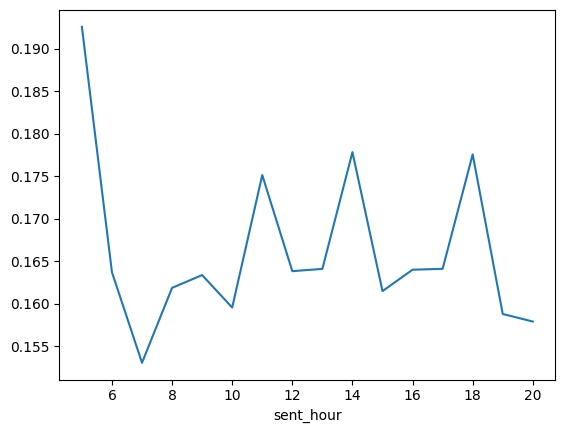

In [62]:
df2.groupby("sent_hour")["target_opened"].mean().plot()

<Axes: xlabel='sent_dow'>

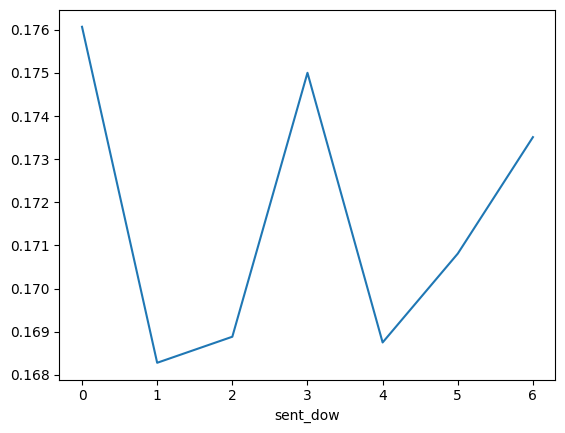

In [63]:
df2.groupby("sent_dow")["target_opened"].mean().plot()

### 과거이력 left truncation
- 과거에 받은 적이 있냐 없냐, 몇번 받았냐 몇번 열었냐 -> 최근 n일에 받았냐로 수정

In [6]:
import duckdb

con = duckdb.connect()

path = "./processed/email_click_trigger_demo_with_history.parquet"

df = con.sql(f"""
    SELECT *
    FROM read_parquet('{path}')
""").df()

df.shape

(2138268, 68)

In [7]:
df2 = df.copy()

df2["sent_at"] = pd.to_datetime(df2["sent_at"])

# 고객별 과거 이력을 시간 순서대로 정확히 계산하기 위해 정렬 
df2 = df2.sort_values(
    ["client_id", "sent_at", "message_row_id"]
).reset_index(drop=True)

In [8]:
df2.head()

,message_row_id,message_id,client_id,campaign_id,campaign_type,category,platform,email_provider,stream,message_date,sent_at,sent_year,sent_month,sent_dow,sent_hour,campaign_channel,topic,campaign_total_count,campaign_ab_test,campaign_warmup_mode,campaign_hour_limit,subject_length,subject_with_personalization,subject_with_deadline,subject_with_emoji,subject_with_bonuses,subject_with_discount,subject_with_saleout,campaign_is_test,campaign_position,had_purchased_before_send,days_since_first_purchase,is_holiday,days_to_next_holiday,days_since_prev_holiday,target_opened,target_clicked,target_unsubscribed,target_hard_bounced,target_soft_bounced,target_complained,target_blocked,target_purchased,past_email_sent_count,past_email_open_count,past_email_click_count,past_email_purchase_count,past_email_unsubscribe_count,past_email_complaint_count,past_email_hard_bounce_count,past_email_soft_bounce_count,past_email_block_count,past_bulk_sent_count,past_trigger_sent_count,past_transactional_sent_count,past_bulk_open_count,past_trigger_open_count,past_transactional_open_count,past_bulk_click_count,past_trigger_click_count,past_transactional_click_count,past_email_open_rate,past_email_click_rate,past_email_purchase_rate,days_since_last_email,days_since_last_open,days_since_last_click,days_since_last_purchase
0,18006688,7c48ccee-e2a6-4b50-a5d3-7c1dc8016f12,1515915625467997301,18011,trigger,None,desktop,private,desktop,2021-04-30,2021-04-30 09:00:18,2021,4,5,9,multichannel,abandoned category,<NA>,False,False,<NA>,NaN,False,False,False,False,False,False,False,3,0,<NA>,0,1,29,1,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>
1,18006690,a83c435e-4d05-4a1e-af01-9d67913f371a,1515915625467997301,18011,trigger,None,NaN,private,desktop,2021-04-30,2021-04-30 13:06:09,2021,4,5,13,multichannel,abandoned category,<NA>,False,False,<NA>,NaN,False,False,False,False,False,False,False,3,0,<NA>,0,1,29,0,0,0,0,0,0,0,0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0,0,<NA>,<NA>
2,18006689,fbb0af74-6330-4fc8-a501-06abcc52e257,1515915625467997301,18010,trigger,None,desktop,private,desktop,2021-04-30,2021-04-30 16:07:05,2021,4,5,16,multichannel,abandoned cart,<NA>,False,False,<NA>,NaN,False,False,False,False,False,False,False,4,0,<NA>,0,1,29,1,0,0,0,0,0,0,0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.500000,0.0,0.0,0,0,<NA>,<NA>
3,18219075,d533bea7-63d7-4330-a73a-c1ad0b5f876c,1515915625467997301,19017,trigger,None,NaN,private,desktop,2021-05-04,2021-05-04 08:27:03,2021,5,2,8,multichannel,abandoned search,<NA>,False,False,<NA>,NaN,False,False,False,False,False,False,False,7,0,<NA>,0,5,3,0,0,0,0,0,0,0,0,3.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.666667,0.0,0.0,4,4,<NA>,<NA>
4,18219074,68f1a67b-cb28-4301-95a5-83304ebf8e6b,1515915625467997301,18011,trigger,None,NaN,private,desktop,2021-05-04,2021-05-04 09:08:17,2021,5,2,9,multichannel,abandoned category,<NA>,False,False,<NA>,NaN,False,False,False,False,False,False,False,3,0,<NA>,0,5,3,0,0,0,0,0,0,0,0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.500000,0.0,0.0,0,4,<NA>,<NA>


In [9]:
def add_trigger_rolling_features(df, windows=("7D", "14D")):
    """
    각 trigger 이메일 행마다, 같은 고객이 직전 7일/14일 동안 받은 trigger 이력을 계산하는 함수
    """
    df = df.copy()
    df = df.sort_values(["client_id", "sent_at", "message_row_id"])
    df = df.set_index("sent_at")

    for window in windows:
        suffix = window.lower()

        df[f"trigger_sent_count_{suffix}"] = (
            df.groupby("client_id")["target_opened"]
              .rolling(window, closed="left")
              .count()
              .reset_index(level=0, drop=True)
        )

        df[f"trigger_open_count_{suffix}"] = (
            df.groupby("client_id")["target_opened"]
              .rolling(window, closed="left")
              .sum()
              .reset_index(level=0, drop=True)
        )

        df[f"trigger_click_count_{suffix}"] = (
            df.groupby("client_id")["target_clicked"]
              .rolling(window, closed="left")
              .sum()
              .reset_index(level=0, drop=True)
        )

    df = df.reset_index()

    return df

In [10]:
df2 = add_trigger_rolling_features(df2, windows=("7D", "14D"))

df2.shape

(2138268, 74)

In [12]:
rolling_cols = [
    "trigger_sent_count_7d",
    "trigger_open_count_7d",
    "trigger_click_count_7d",
    "trigger_sent_count_14d",
    "trigger_open_count_14d",
    "trigger_click_count_14d",
]

df2[rolling_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
trigger_sent_count_7d,1119261.0,4.319738,4.190835,1.0,1.0,3.0,6.0,48.0
trigger_open_count_7d,1119261.0,0.758945,1.867527,0.0,0.0,0.0,1.0,41.0
trigger_click_count_7d,1119261.0,0.253627,0.824639,0.0,0.0,0.0,0.0,22.0
trigger_sent_count_14d,1239537.0,5.996292,6.785331,1.0,2.0,4.0,8.0,78.0
trigger_open_count_14d,1239537.0,1.030006,2.736077,0.0,0.0,0.0,1.0,69.0
trigger_click_count_14d,1239537.0,0.332973,1.146042,0.0,0.0,0.0,0.0,39.0


In [13]:
df2[rolling_cols].isna().mean().mul(100) #7,14 이내에 이력이 없던 애들

trigger_sent_count_7d      47.655719
trigger_open_count_7d      47.655719
trigger_click_count_7d     47.655719
trigger_sent_count_14d     42.030793
trigger_open_count_14d     42.030793
trigger_click_count_14d    42.030793
dtype: float64

In [14]:
min_sent_at = df2["sent_at"].min()

# 가장 예전 발송 시점부터 7일, 14일 이후의 데이터만 남기기(burn-in period)
for days in [7, 14]:
    cutoff = min_sent_at + pd.Timedelta(days=days)
    remain = df2[df2["sent_at"] >= cutoff]

    print(f"{days}일 burn-in")
    print("cutoff:", cutoff)
    print("rows:", len(remain))
    print("row_pct:", len(remain) / len(df2) * 100)
    print("open_rate:", remain["target_opened"].mean())
    print()

# 앞의 7일차를 제거하는거는 가능함. 데이토 손실도 적고 기존의 open_rate와도 크게 다르지 않음. 14일차는 데이터 손실이 너무 큼. 

7일 burn-in
cutoff: 2021-05-07 05:00:07
rows: 1794377
row_pct: 83.9173106458124
open_rate: 0.1697447080518754

14일 burn-in
cutoff: 2021-05-14 05:00:07
rows: 1471653
row_pct: 68.82453462334936
open_rate: 0.17104779455483052



In [15]:
df2[["sent_at"] + rolling_cols].head(30)

,sent_at,trigger_sent_count_7d,trigger_open_count_7d,trigger_click_count_7d,trigger_sent_count_14d,trigger_open_count_14d,trigger_click_count_14d
0,2021-04-30 09:00:18,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-04-30 13:06:09,1.0,1.0,0.0,1.0,1.0,0.0
2,2021-04-30 16:07:05,2.0,1.0,0.0,2.0,1.0,0.0
3,2021-05-04 08:27:03,3.0,2.0,0.0,3.0,2.0,0.0
4,2021-05-04 09:08:17,4.0,2.0,0.0,4.0,2.0,0.0
5,2021-05-04 10:50:35,5.0,2.0,0.0,5.0,2.0,0.0
6,2021-05-04 13:31:45,6.0,2.0,0.0,6.0,2.0,0.0
7,2021-05-06 10:21:30,7.0,3.0,0.0,7.0,3.0,0.0
8,2021-05-06 14:46:15,8.0,3.0,0.0,8.0,3.0,0.0
9,2021-05-07 07:55:21,9.0,4.0,0.0,9.0,4.0,0.0


In [ ]:
## 저장
con = duckdb.connect()

con.register("df2_view", df2)

con.sql("""
COPY df2_view
TO './processed/email_click_trigger_demo_with_history_rolling.parquet'
(FORMAT PARQUET, COMPRESSION ZSTD)
""")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
# "trigger_sent_count_7d",
# "trigger_open_count_7d",
# "trigger_click_count_7d",
## count별 오픈률 확인
for col in [
    "trigger_sent_count_7d",
    "trigger_open_count_7d",
    "trigger_click_count_7d",
]:
    display(
        df2.groupby(col)["target_opened"]
           .agg(count="size", open_rate="mean")
           .reset_index()
           .sort_values(col)
    )

,trigger_sent_count_7d,count,open_rate
0,1.0,297384,0.158105
1,2.0,200688,0.149665
2,3.0,143733,0.148407
3,4.0,106382,0.148371
4,5.0,80352,0.149131
5,6.0,61651,0.148075
6,7.0,47815,0.151982
7,8.0,37476,0.153618
8,9.0,29199,0.150964
9,10.0,23093,0.158749


,trigger_open_count_7d,count,open_rate
0,0.0,772795,0.056375
1,1.0,178524,0.284998
2,2.0,69730,0.367862
3,3.0,34684,0.438963
4,4.0,20004,0.493951
5,5.0,12636,0.531497
6,6.0,8389,0.570390
7,7.0,5930,0.600000
8,8.0,3856,0.663900
9,9.0,2936,0.676771


,trigger_click_count_7d,count,open_rate
0,0.0,949899,0.111566
1,1.0,115297,0.341336
2,2.0,29263,0.442948
3,3.0,11207,0.508343
4,4.0,5647,0.564193
5,5.0,3040,0.585855
6,6.0,1818,0.630913
7,7.0,1094,0.679159
8,8.0,682,0.690616
9,9.0,452,0.767699


In [ ]:
## 구간화를 통해 보기 쉽게함
df2["trigger_sent_count_7d_bin"] = pd.cut(
    df2["trigger_sent_count_7d"],
    bins=[-1, 0, 1, 2, 3, float("inf")],
    labels=["0", "1", "2", "3", "4+"]
)

df2["trigger_open_count_7d_bin"] = pd.cut(
    df2["trigger_open_count_7d"],
    bins=[-1, 0, 1, 2, float("inf")],
    labels=["0", "1", "2", "3+"]
)

df2["trigger_click_count_7d_bin"] = pd.cut(
    df2["trigger_click_count_7d"],
    bins=[-1, 0, 1, float("inf")],
    labels=["0", "1", "2+"]
)

In [ ]:
## count별 오픈률 확인 -> 7일이내에 받았냐는 큰 의미가 없어 보이지만 오픈과 클릭은 횟수가 많을수록 오픈률이 높아지는 경향이 보임.
for col in [
    "trigger_sent_count_7d_bin",
    "trigger_open_count_7d_bin",
    "trigger_click_count_7d_bin",
]:
    display(
        df2.groupby(col)["target_opened"]
           .agg(count="size", open_rate="mean")
    )

,count,open_rate
trigger_sent_count_7d_bin,,
1,297384,0.158105
2,200688,0.149665
3,143733,0.148407
4+,477456,0.155038


,count,open_rate
trigger_open_count_7d_bin,,
0,772795,0.056375
1,178524,0.284998
2,69730,0.367862
3+,98212,0.532654


,count,open_rate
trigger_click_count_7d_bin,,
0,949899,0.111566
1,115297,0.341336
2+,54065,0.500842


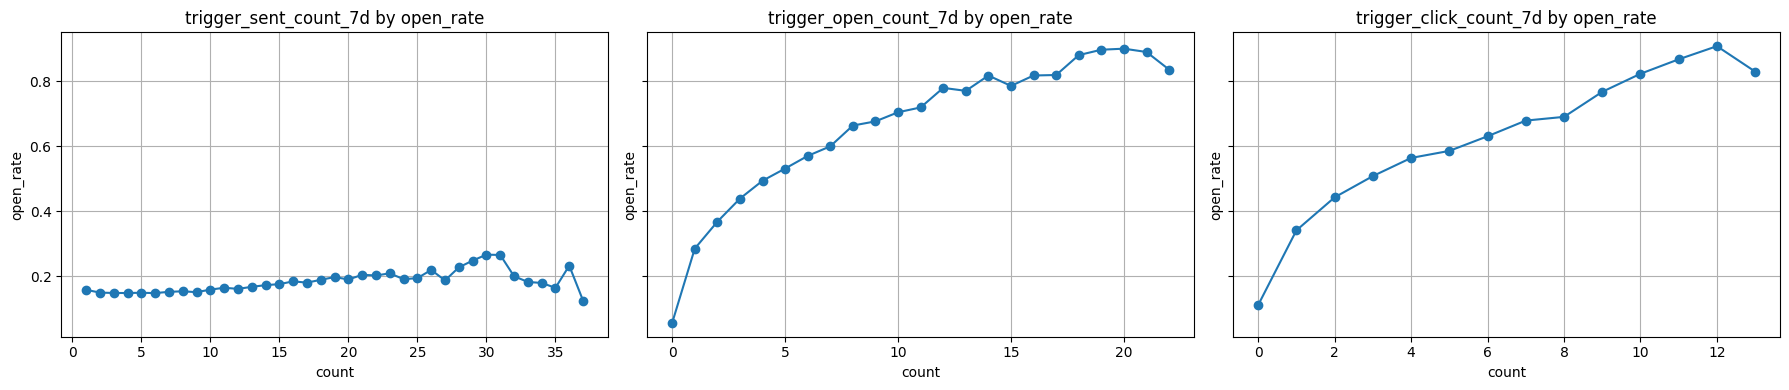

In [26]:
import matplotlib.pyplot as plt

cols = [
    "trigger_sent_count_7d",
    "trigger_open_count_7d",
    "trigger_click_count_7d",
]

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, col in zip(axes, cols):
    summary = (
        df2.groupby(col)["target_opened"]
           .agg(count="size", open_rate="mean")
           .reset_index()
           .sort_values(col)
    )

    plot_df = summary[summary["count"] >= 100]

    ax.plot(plot_df[col], plot_df["open_rate"], marker="o")
    ax.set_title(f"{col} by open_rate")
    ax.set_xlabel("count")
    ax.set_ylabel("open_rate")
    ax.grid(True)

plt.tight_layout()
plt.show()

#### 2차 모델링

In [ ]:
features_7d = [
    "topic",
    "email_provider_grouped",
    "sent_dow",
    "sent_hour",

    "trigger_sent_count_7d",
    "trigger_open_count_7d",
    "trigger_click_count_7d",
]

In [ ]:
# rolling NaN은 "최근 7일 이력 없음"이므로 0 처리(7일이내에 받은게 없는거임 받은게 없으니 액션도 없음   )
rolling_7d_cols = [
    "trigger_sent_count_7d",
    "trigger_open_count_7d",
    "trigger_click_count_7d",
]

df[rolling_7d_cols] = df[rolling_7d_cols].fillna(0)

In [82]:
min_sent_at = df["sent_at"].min()
cutoff_7d = min_sent_at + pd.Timedelta(days=7)

df_7d = df[df["sent_at"] >= cutoff_7d].copy()

df_7d.shape, df_7d["target_opened"].mean()

((1794377, 74), np.float64(0.1697447080518754))

In [84]:
df_7d = df_7d[df_7d["topic"] != "price drop"].copy()

In [83]:
top_providers = (
    df_7d["email_provider"]
    .value_counts()
    .head(10)
    .index
)

df_7d["email_provider_grouped"] = df_7d["email_provider"].where(
    df_7d["email_provider"].isin(top_providers),
    "other"
)

In [ ]:
features_7d = [
    "topic",
    "email_provider_grouped",
    "sent_dow",
    "sent_hour",
    "trigger_sent_count_7d",
    "trigger_open_count_7d",
    "trigger_click_count_7d",
]

target = "target_opened"

cat_cols = [
    "topic",
    "email_provider_grouped",
]

In [86]:
for col in cat_cols:
    df_7d[col] = df_7d[col].astype("category")

In [87]:
df_7d["sent_dow"] = df_7d["sent_dow"].astype(int)
df_7d["sent_hour"] = df_7d["sent_hour"].astype(int)

In [89]:
df_7d = df_7d.sort_values("sent_at").reset_index(drop=True)

split_idx = int(len(df_7d) * 0.8)

train_df = df_7d.iloc[:split_idx].copy()
test_df = df_7d.iloc[split_idx:].copy()

X_train = train_df[features_7d]
y_train = train_df[target].astype(int)

X_test = test_df[features_7d]
y_test = test_df[target].astype(int)

In [90]:
lgbm_7d = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

lgbm_7d.fit(
    X_train,
    y_train,
    categorical_feature=cat_cols
)

[LightGBM] [Info] Number of positive: 243503, number of negative: 1191949
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028913 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 144
[LightGBM] [Info] Number of data points in the train set: 1435452, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [92]:
result,cm =evaluate_model("LightGBM 7D", lgbm_7d, X_test, y_test)

In [100]:
result_df = pd.DataFrame([result])
result_df


,model,roc_auc,pr_auc,accuracy,precision,recall,f1
0,LightGBM 7D,0.748628,0.446981,0.630621,0.277458,0.729583,0.402026


In [102]:
display(cm)
tn, fp, fn, tp = cm.ravel()

display(pd.DataFrame({
    "count": [tn, fp, fn, tp]
}, index=["TN 실제0_예측0", "FP 실제0_예측1", "FN 실제1_예측0", "TP 실제1_예측1"]))

array([[181747, 116041],
       [ 16516,  44560]])

,count
TN 실제0_예측0,181747
FP 실제0_예측1,116041
FN 실제1_예측0,16516
TP 실제1_예측1,44560


- 1차보다 성능이 비약적으로 상승함 특히 auc가 점수가 높은것으로 보아 임계값을 조정한다면 다른 지표의 성능이 오를것도 기대할수 있을듯 함

In [103]:
pred_proba = lgbm_7d.predict_proba(X_test)[:, 1]
pred = (pred_proba >= 0.5).astype(int)

In [104]:
thresholds = np.arange(0.1, 0.91, 0.05)

threshold_results = []

for th in thresholds:
    pred = (pred_proba >= th).astype(int)

    threshold_results.append({
        "threshold": th,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "pred_open_rate": pred.mean(),
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,threshold,accuracy,precision,recall,f1,pred_open_rate
0,0.10,0.183671,0.172346,0.998477,0.293953,0.986003
1,0.15,0.236078,0.180967,0.989423,0.305972,0.930514
2,0.20,0.311965,0.194655,0.969841,0.324233,0.847962
3,0.25,0.386968,0.209944,0.941663,0.343340,0.763367
4,0.30,0.438545,0.222068,0.918429,0.357658,0.703882
5,0.35,0.484027,0.233341,0.888925,0.369650,0.648357
6,0.40,0.522633,0.243620,0.857522,0.379442,0.599063
7,0.45,0.593846,0.265315,0.783696,0.396424,0.502720
8,0.50,0.630621,0.277458,0.729583,0.402026,0.447526
9,0.55,0.765282,0.363115,0.502865,0.421714,0.235694


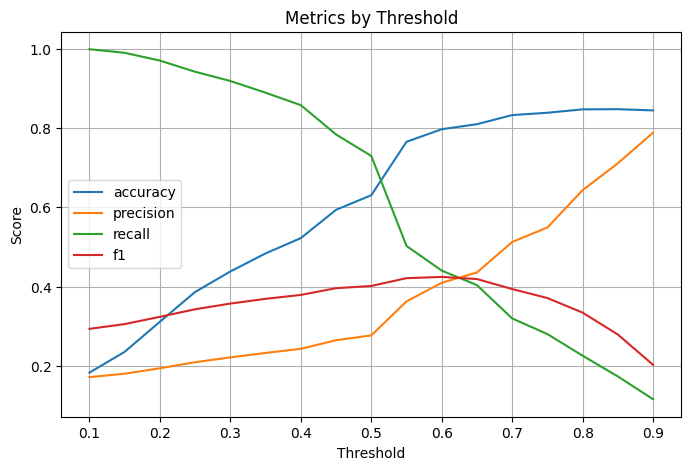

In [105]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(threshold_df["threshold"], threshold_df["accuracy"], label="accuracy")
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="f1")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Metrics by Threshold")
plt.legend()
plt.grid(True)
plt.show()